# Financial Market Sentiment Prediction

This notebook is a **thin orchestrator**. All reusable logic lives in the
installable `financial_sentiment` package under [`src/`](../src/financial_sentiment);
the notebook only wires the pieces together and visualises results.

**Pipeline**: load data → clean/normalise text → TF-IDF + classical ML baselines →
fine-tune RoBERTa → compare.

> Run `pip install -e ".[boosting,transformers,dev]"` from the repo root first.

## 1. Setup

In [1]:
# Make the src/ package importable when running the notebook in-place.
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from financial_sentiment.config import load_settings
from financial_sentiment.utils import configure_logging, set_global_seed

configure_logging()
settings = load_settings(PROJECT_ROOT / 'configs' / 'default.yaml')
set_global_seed(settings.random_seed)
settings

c:\Users\Erick\Documents\vscode\ml-financial-sentiment-analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-06-26 18:02:05 | INFO     | financial_sentiment.utils.seed | Global random seed set to 42.


Settings(random_seed=42, output_dir=WindowsPath('outputs'), data=DataConfig(data_path=WindowsPath('notebooks/data.csv'), text_column='Sentence', label_column='Sentiment', drop_duplicates=True), ml=MLConfig(test_size=0.25, tfidf_min_df=2e-05, tfidf_max_df=0.7, use_idf=True), transformer=TransformerConfig(model_checkpoint='roberta-base', model_path=WindowsPath('outputs/roberta-finetuned'), num_labels=3, max_length=128, test_size=0.1, validation_size=0.2, train_batch_size=32, eval_batch_size=32, epochs=5, lr=3e-05, adam_epsilon=1e-08, num_warmup_steps=10))

## 2. Load & preprocess

`load_dataset` reads the CSV, removes duplicates and encodes labels. `TextCleaner`
applies vectorised regex cleaning; token-level normalisation (stemming +
lemmatisation) is applied **only** for the classical ML models — transformers
perform better on minimally processed text.

In [2]:
from financial_sentiment.data import load_dataset
from financial_sentiment.preprocessing import TextCleaner

dataset = load_dataset(settings.data)
text_col = settings.data.text_column

cleaner = TextCleaner()
ml_frame = cleaner.clean_dataframe(dataset.frame, text_col)
ml_frame[text_col] = cleaner.normalize_series(ml_frame[text_col])
ml_frame.head()

2026-06-26 18:02:07 | INFO     | financial_sentiment.data.loader | Loading dataset from C:\Users\Erick\Documents\vscode\ml-financial-sentiment-analysis\notebooks\data.csv
2026-06-26 18:02:07 | INFO     | financial_sentiment.data.loader | Dropped 520 duplicate rows.
2026-06-26 18:02:07 | INFO     | financial_sentiment.data.loader | Loaded 5322 rows across 3 classes: ['negative', 'neutral', 'positive']
2026-06-26 18:02:08 | INFO     | financial_sentiment.utils.nltk_resources | Downloading missing NLTK resource: wordnet
2026-06-26 18:02:08 | INFO     | financial_sentiment.utils.nltk_resources | Downloading missing NLTK resource: omw-1.4


,Sentence,Sentiment,labels
0,geosolut technolog leverag benefon gps solut p...,positive,2
1,esi low bk real possibl,negative,0
2,quarter componenta net sale doubl eur eur peri...,positive,2
3,accord finnish russian chamber commerc major c...,neutral,1
4,swedish buyout firm sold remain percent stake ...,neutral,1


## 3. Exploratory Data Analysis

`summarize_dataset` profiles the dataset with **pandas only** — shape, dtypes,
missing values, duplicates, class balance and text-length statistics — so EDA
works on any Python version without extra dependencies.

In [3]:
from financial_sentiment.data import summarize_dataset

# Pandas-only profile. Profile the raw data, before cleaning.
summary = summarize_dataset(
    dataset.frame,
    text_column=settings.data.text_column,
    label_column=settings.data.label_column,
)

display(summary.overview)
display(summary.dtypes)
display(summary.class_distribution)
display(summary.text_length)

2026-06-26 18:02:11 | INFO     | financial_sentiment.data.exploration | Profiling dataset (5322 rows).


,rows,columns,duplicate_texts,total_missing,memory_kb
0,5322,3,0,0,768.6


,dtype,missing,missing_pct,unique
Sentence,str,0,0.0,5322
Sentiment,str,0,0.0,3
labels,int64,0,0.0,3


,count,percentage
Sentiment,,
neutral,2878,54.08
positive,1852,34.80
negative,592,11.12


,char_count,word_count
overall_mean,116.1,20.7
overall_min,9.0,2.0
overall_max,315.0,81.0
mean[negative],97.8,17.4
mean[neutral],122.4,21.9
mean[positive],112.2,19.9


## 4. Classical ML baseline

2026-06-26 18:02:11 | INFO     | financial_sentiment.utils.seed | Global random seed set to 42.
2026-06-26 18:02:11 | INFO     | financial_sentiment.data.loader | Loading dataset from C:\Users\Erick\Documents\vscode\ml-financial-sentiment-analysis\notebooks\data.csv
2026-06-26 18:02:11 | INFO     | financial_sentiment.data.loader | Dropped 520 duplicate rows.
2026-06-26 18:02:11 | INFO     | financial_sentiment.data.loader | Loaded 5322 rows across 3 classes: ['negative', 'neutral', 'positive']
2026-06-26 18:02:12 | INFO     | financial_sentiment.pipelines.ml_pipeline | TF-IDF features — train: (3991, 6207), test: (1331, 6207)
2026-06-26 18:02:12 | WARNING  | financial_sentiment.models.ml | lightgbm not installed; skipping LightGBM.
2026-06-26 18:02:12 | WARNING  | financial_sentiment.models.ml | xgboost not installed; skipping XGBoost.
2026-06-26 18:02:12 | INFO     | financial_sentiment.models.ml | Training Random Forest ...
2026-06-26 18:02:15 | INFO     | financial_sentiment.models

c:\Users\Erick\Documents\vscode\ml-financial-sentiment-analysis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:792: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


2026-06-26 18:02:39 | INFO     | financial_sentiment.evaluation.plots | Saved accuracy plot to outputs\ml_accuracies.png


[ModelResult(name='Support Vector Machine', accuracy=0.7362885048835462),
 ModelResult(name='Random Forest', accuracy=0.71900826446281),
 ModelResult(name='Multilayer Perceptron', accuracy=0.7145003756574004),
 ModelResult(name='Gradient Boosting', accuracy=0.7024793388429752),
 ModelResult(name='Naive Bayes', accuracy=0.6942148760330579),
 ModelResult(name='Decision Tree', accuracy=0.6694214876033058),
 ModelResult(name='AdaBoost', accuracy=0.5822689706987227)]

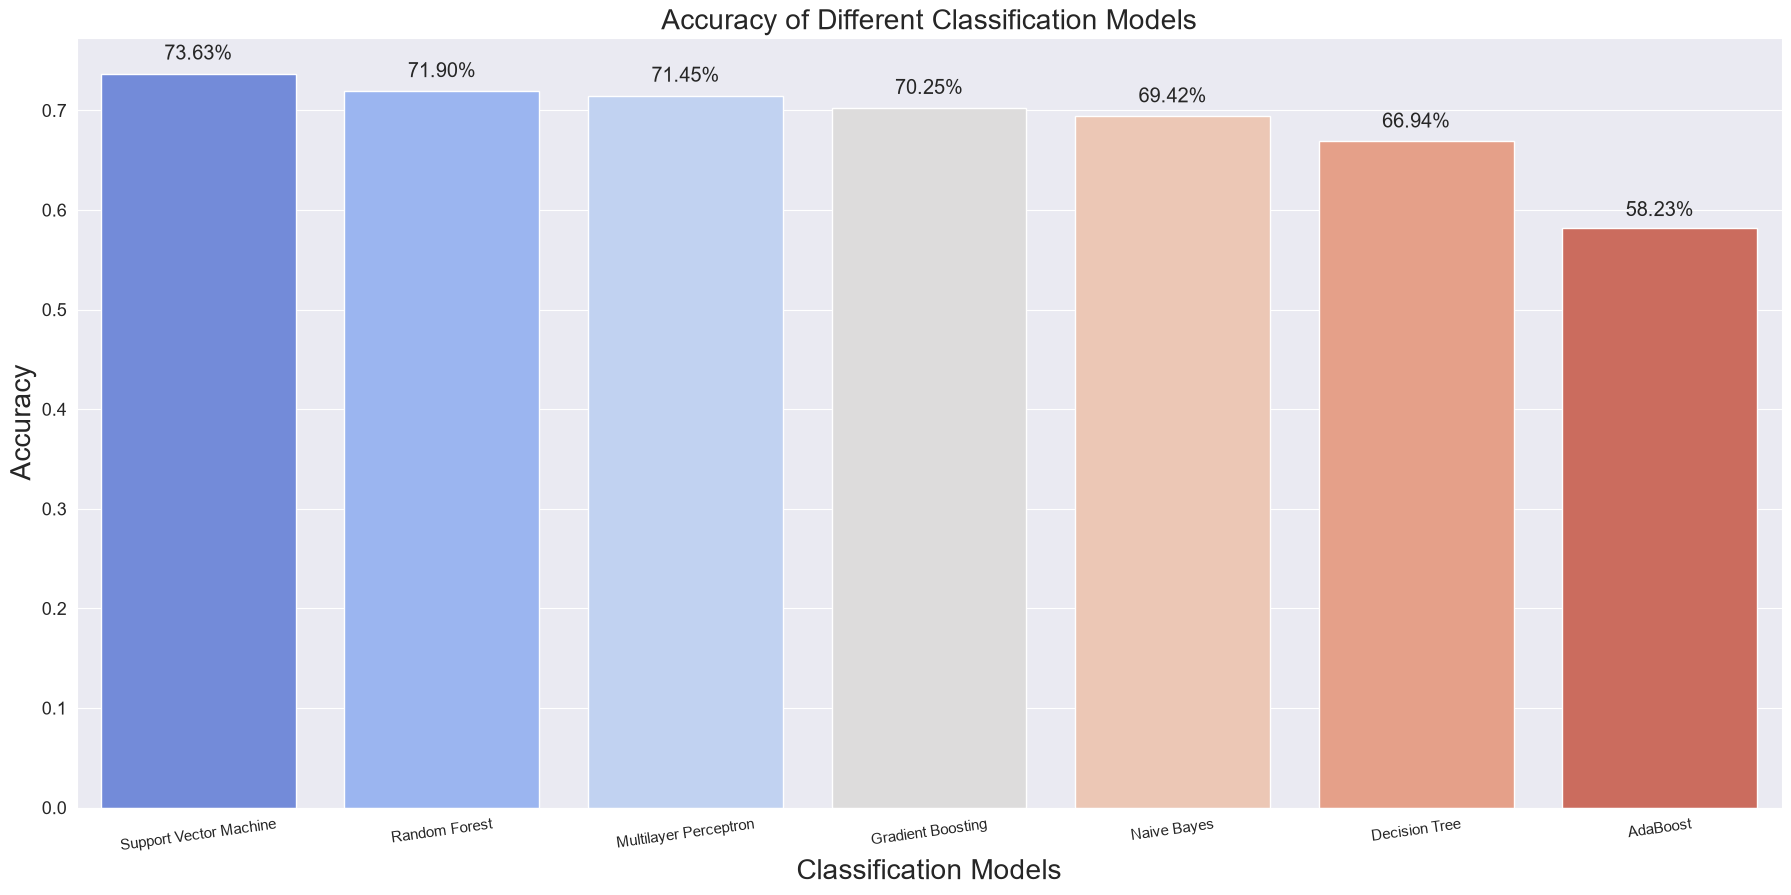

In [4]:
from financial_sentiment.pipelines.ml_pipeline import run as run_ml

ml_results = run_ml(settings)
ml_results

## 5. Transformers to the rescue

Fine-tune RoBERTa via HuggingFace Accelerate (runs on CPU/GPU/TPU unchanged).
Requires the `transformers` extra and is GPU-intensive.

In [ ]:
# To fine-tune RoBERTa (long-running, needs a GPU):
from financial_sentiment.pipelines.transformer_pipeline import run as run_transformer
history = run_transformer(settings)
history

## 6. Conclusion — model comparison

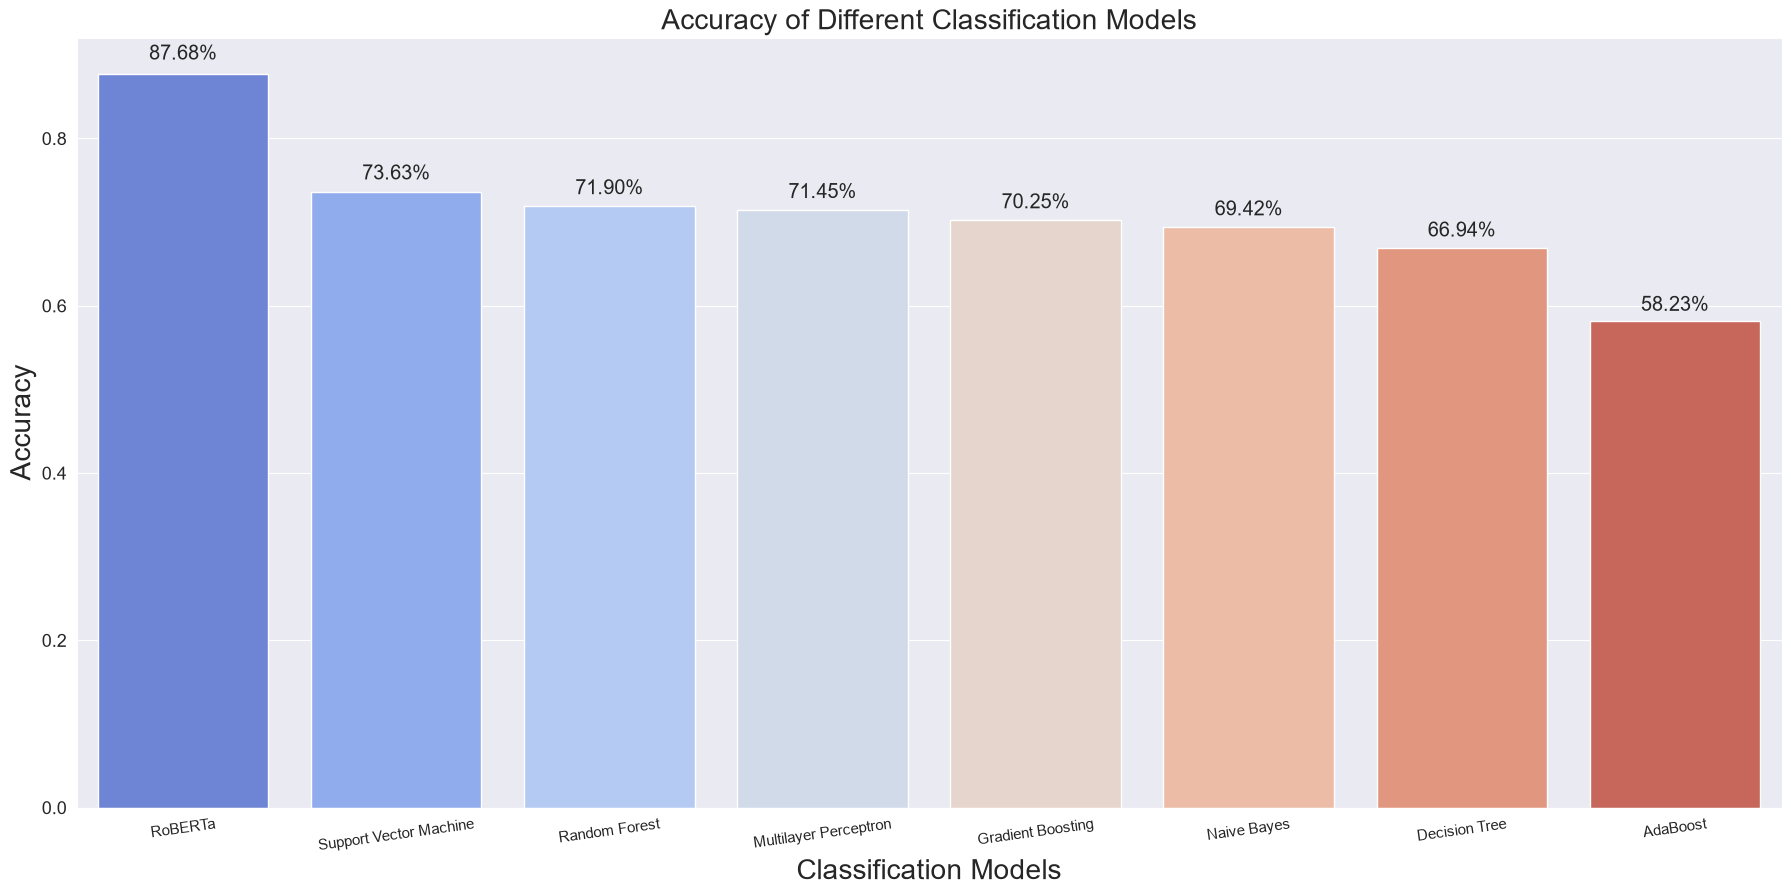

,Model,Accuracy
0,RoBERTa,0.876800
1,Support Vector Machine,0.736289
2,Random Forest,0.719008
3,Multilayer Perceptron,0.714500
4,Gradient Boosting,0.702479
5,Naive Bayes,0.694215
6,Decision Tree,0.669421
7,AdaBoost,0.582269


In [5]:
from financial_sentiment.evaluation import results_to_frame, plot_model_accuracies
from financial_sentiment.models import ModelResult

# Best validation accuracy observed for the fine-tuned RoBERTa run.
ROBERTA_ACCURACY = 0.8768
all_results = list(ml_results) + [ModelResult('RoBERTa', ROBERTA_ACCURACY)]

frame = results_to_frame(all_results)
plot_model_accuracies(frame, show=True)
frame